# Notebook 1 — Data Preparation
## Smart Sniper Spotter · Target Detection Module

This notebook prepares the person-detection training data by:

1. **COCO 2017** — filtering for outdoor images containing persons
2. **WiderPerson** — downloading and parsing annotations
3. **Merging** both datasets into a unified annotation format
4. **Emitting YOLO labels** — normalized `(class cx cy w h)` txt files in the standard YOLO directory layout
5. **Saving output** as a reusable Kaggle dataset for the unifier notebook

### Kaggle Setup (before running)
1. Create a new Kaggle notebook (CPU, no GPU needed)
2. **Add dataset:** Search for `coco-2017-dataset` and attach it
3. **Enable Internet** in notebook settings (needed for WiderPerson download)
4. Upload this notebook and run all cells

## 1. Environment Setup

In [1]:
# Install required packages (YOLO output — no TensorFlow needed for emission)
!pip install -q pycocotools gdown pillow tqdm

import os
import json
import glob
import random
import shutil
import hashlib
from pathlib import Path
from collections import defaultdict

import numpy as np
from pycocotools.coco import COCO

print("Imports OK")

Imports OK


In [2]:
# =============================================================================
# CONFIGURATION — adjust paths if your Kaggle dataset attachment differs
# =============================================================================

# COCO 2017 paths (attached Kaggle dataset — read-only)
# Common Kaggle dataset slugs: "awsaf49/coco-2017-dataset", "sabahesaraki/2017-2017"
# Adjust COCO_ROOT if your attachment uses a different directory structure.
COCO_ROOT = None  # Auto-detected below

# Search for COCO in /kaggle/input
for candidate in Path("/kaggle/input").iterdir():
    for ann_path in candidate.rglob("instances_train2017.json"):
        COCO_ROOT = str(candidate)
        break
    if COCO_ROOT:
        break

if COCO_ROOT is None:
    raise FileNotFoundError(
        "COCO 2017 not found in /kaggle/input/. "
        "Please attach a COCO 2017 dataset to this notebook. "
        "Search Kaggle datasets for 'coco-2017-dataset'."
    )

# Locate exact subdirectories
COCO_ANN_DIR = None
COCO_TRAIN_IMG_DIR = None
COCO_VAL_IMG_DIR = None

for p in Path(COCO_ROOT).rglob("instances_train2017.json"):
    COCO_ANN_DIR = str(p.parent)
for p in Path(COCO_ROOT).rglob("train2017"):
    if p.is_dir():
        COCO_TRAIN_IMG_DIR = str(p)
for p in Path(COCO_ROOT).rglob("val2017"):
    if p.is_dir():
        COCO_VAL_IMG_DIR = str(p)

print(f"COCO root:        {COCO_ROOT}")
print(f"COCO annotations: {COCO_ANN_DIR}")
print(f"COCO train imgs:  {COCO_TRAIN_IMG_DIR}")
print(f"COCO val imgs:    {COCO_VAL_IMG_DIR}")

# Working directories — YOLO nested layout
# images/{train,val} and labels/{train,val} + data.yaml at the root.
WORK_DIR = "/kaggle/working"
WIDER_DIR = os.path.join(WORK_DIR, "WiderPerson")
OUTPUT_DIR = os.path.join(WORK_DIR, "person_bulk_yolo")

IMG_TRAIN_DIR = os.path.join(OUTPUT_DIR, "images", "train")
IMG_VAL_DIR   = os.path.join(OUTPUT_DIR, "images", "val")
LBL_TRAIN_DIR = os.path.join(OUTPUT_DIR, "labels", "train")
LBL_VAL_DIR   = os.path.join(OUTPUT_DIR, "labels", "val")

for d in (IMG_TRAIN_DIR, IMG_VAL_DIR, LBL_TRAIN_DIR, LBL_VAL_DIR):
    os.makedirs(d, exist_ok=True)

# Dataset parameters
RANDOM_SEED = 42
VAL_FRACTION = 0.10  # 10% of combined data for validation

# Class scheme (unified project): person=0, drone=1. This notebook emits person only.
PERSON_CLASS_ID = 0

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(f"\nOutput directory:  {OUTPUT_DIR}")
print(f"  images/train, images/val, labels/train, labels/val")

COCO root:        /kaggle/input/datasets
COCO annotations: /kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/annotations
COCO train imgs:  /kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/train2017
COCO val imgs:    /kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/val2017

Output directory:  /kaggle/working/person_bulk_yolo
  images/train, images/val, labels/train, labels/val


## 2. Filter COCO 2017 for Outdoor Person Images

We extract images containing the `person` class and exclude obviously indoor scenes 
using a heuristic: if all non-person objects in an image belong to indoor-indicator 
categories (bed, couch, toilet, oven, etc.), the image is excluded.

Each annotation is stored as:
```python
{
    "image_path": str,
    "width": int,
    "height": int,
    "boxes": [(xmin, ymin, xmax, ymax), ...],  # absolute pixel coordinates
    "source": "coco"
}
```


In [3]:
# COCO category IDs for indoor-indicator objects
# These are used to filter out obviously indoor images
INDOOR_CATEGORY_NAMES = {
    "bed", "couch", "dining table", "toilet", "tv", "laptop",
    "mouse", "remote", "keyboard", "cell phone", "microwave",
    "oven", "toaster", "sink", "refrigerator"
}

def filter_coco_person_outdoor(ann_file, img_dir):
    """
    Filter COCO for images containing persons in likely outdoor settings.
    
    Returns a list of annotation dicts with unified format.
    """
    coco = COCO(ann_file)
    
    # Get person category ID
    person_cat_ids = coco.getCatIds(catNms=["person"])
    if not person_cat_ids:
        raise ValueError("'person' category not found in COCO annotations")
    person_cat_id = person_cat_ids[0]
    
    # Get indoor category IDs
    all_cats = {c["id"]: c["name"] for c in coco.loadCats(coco.getCatIds())}
    indoor_cat_ids = {cid for cid, name in all_cats.items() if name in INDOOR_CATEGORY_NAMES}
    
    # Get all image IDs containing person
    person_img_ids = set(coco.getImgIds(catIds=person_cat_ids))
    print(f"  Total images with person: {len(person_img_ids)}")
    
    results = []
    skipped_indoor = 0
    skipped_no_box = 0
    
    for img_id in sorted(person_img_ids):
        img_info = coco.loadImgs(img_id)[0]
        img_path = os.path.join(img_dir, img_info["file_name"])
        
        if not os.path.exists(img_path):
            continue
        
        # Get all annotations for this image
        ann_ids = coco.getAnnIds(imgIds=img_id)
        anns = coco.loadAnns(ann_ids)
        
        # Check indoor heuristic: collect non-person category IDs in this image
        non_person_cats = {a["category_id"] for a in anns if a["category_id"] != person_cat_id}
        
        # If there ARE non-person objects and ALL of them are indoor → skip
        if non_person_cats and non_person_cats.issubset(indoor_cat_ids):
            skipped_indoor += 1
            continue
        
        # Extract person bounding boxes (skip crowd or tiny annotations)
        boxes = []
        for a in anns:
            if a["category_id"] != person_cat_id:
                continue
            if a.get("iscrowd", 0):
                continue
            x, y, w, h = a["bbox"]  # COCO format: [x, y, width, height]
            if w < 5 or h < 5:
                continue
            boxes.append((x, y, x + w, y + h))  # Convert to (xmin, ymin, xmax, ymax)
        
        if not boxes:
            skipped_no_box += 1
            continue
        
        results.append({
            "image_path": img_path,
            "width": img_info["width"],
            "height": img_info["height"],
            "boxes": boxes,
            "source": "coco"
        })
    
    print(f"  Kept: {len(results)} | Skipped indoor: {skipped_indoor} | No valid boxes: {skipped_no_box}")
    return results

# Process COCO train split
print("Filtering COCO train2017...")
coco_train_ann = os.path.join(COCO_ANN_DIR, "instances_train2017.json")
coco_train_data = filter_coco_person_outdoor(coco_train_ann, COCO_TRAIN_IMG_DIR)

# Process COCO val split (we'll merge and re-split later)
print("\nFiltering COCO val2017...")
coco_val_ann = os.path.join(COCO_ANN_DIR, "instances_val2017.json")
coco_val_data = filter_coco_person_outdoor(coco_val_ann, COCO_VAL_IMG_DIR)

coco_all = coco_train_data + coco_val_data
print(f"\nTotal COCO outdoor-person images: {len(coco_all)}")


Filtering COCO train2017...
loading annotations into memory...
Done (t=18.74s)
creating index...
index created!
  Total images with person: 64115
  Kept: 61447 | Skipped indoor: 2566 | No valid boxes: 102

Filtering COCO val2017...
loading annotations into memory...
Done (t=0.70s)
creating index...
index created!
  Total images with person: 2693
  Kept: 2571 | Skipped indoor: 117 | No valid boxes: 5

Total COCO outdoor-person images: 64018


## 3. Download and Parse WiderPerson

WiderPerson contains 13,382 images with ~400K person annotations across diverse 
ground-level scenarios. Annotations use the format:

```
<number of annotations>
<class_label> <x1> <y1> <x2> <y2>
...
```

Class labels: 1=pedestrian, 2=rider, 3=partially-visible, 4=ignore, 5=crowd.  
We keep classes 1, 2, and 3 as "person" and skip 4 and 5.


In [4]:
# WiderPerson — attached as Kaggle dataset
WIDER_DIR = None

import subprocess
result = subprocess.run(
    ["find", "/kaggle/input", "-type", "d", "-name", "Images"],
    capture_output=True, text=True
)

for line in result.stdout.strip().split("\n"):
    if "wider" in line.lower():
        WIDER_DIR = str(Path(line).parent)
        break

if WIDER_DIR is None:
    raise FileNotFoundError(
        "WiderPerson not found in /kaggle/input/. "
        "Please attach your WiderPerson dataset to this notebook."
    )

print(f"WiderPerson directory: {WIDER_DIR}")
!ls -la "{WIDER_DIR}"

WiderPerson directory: /kaggle/input/datasets/ritaj1/widerperson
total 116
drwxr-xr-x 5 nobody nogroup     0 Jun 27 12:52 .
drwxr-xr-x 3 root   root     4096 Jun 27 14:35 ..
drwxr-xr-x 2 nobody nogroup     0 Jun 27 12:52 Annotations
drwxr-xr-x 2 nobody nogroup     0 Jun 27 12:51 Evaluation
drwxr-xr-x 2 nobody nogroup     0 Jun 27 12:52 Images
-rw-r--r-- 1 nobody nogroup  2616 Jun 27 12:52 ReadMe.txt
-rw-r--r-- 1 nobody nogroup 35054 Jun 27 12:52 test.txt
-rw-r--r-- 1 nobody nogroup 64000 Jun 27 12:52 train.txt
-rw-r--r-- 1 nobody nogroup  7998 Jun 27 12:52 val.txt


In [5]:
def parse_widerperson(data_dir):
    """
    Parse WiderPerson annotations into unified format.
    
    Returns a list of annotation dicts.
    """
    images_dir = os.path.join(data_dir, "Images")
    annotations_dir = os.path.join(data_dir, "Annotations")
    
    # Check alternative directory structures
    if not os.path.exists(images_dir):
        # Try flat structure
        candidates = list(Path(data_dir).rglob("*.jpg"))
        if candidates:
            images_dir = str(candidates[0].parent)
            print(f"  Found images at: {images_dir}")
    
    if not os.path.exists(annotations_dir):
        candidates = list(Path(data_dir).rglob("*.jpg.txt"))
        if not candidates:
            candidates = list(Path(data_dir).rglob("*.txt"))
        if candidates:
            annotations_dir = str(candidates[0].parent)
            print(f"  Found annotations at: {annotations_dir}")
    
    # Find all annotation files
    ann_files = sorted(glob.glob(os.path.join(annotations_dir, "*.jpg.txt")))
    if not ann_files:
        ann_files = sorted(glob.glob(os.path.join(annotations_dir, "*.txt")))
    
    print(f"  Found {len(ann_files)} annotation files")
    
    # Valid person class labels (1=pedestrian, 2=rider, 3=partially-visible)
    PERSON_LABELS = {1, 2, 3}
    
    results = []
    skipped = 0
    
    for ann_file in ann_files:
        basename = os.path.basename(ann_file).replace(".txt", "")
        if not basename.endswith(".jpg"):
            basename += ".jpg"
        
        img_path = os.path.join(images_dir, basename)
        
        # Try without .jpg.jpg duplication
        if not os.path.exists(img_path):
            basename_alt = os.path.basename(ann_file).replace(".jpg.txt", ".jpg")
            img_path = os.path.join(images_dir, basename_alt)
        
        if not os.path.exists(img_path):
            skipped += 1
            continue
        
        with open(ann_file, "r") as f:
            lines = f.readlines()
        
        if len(lines) < 1:
            skipped += 1
            continue
        
        try:
            num_anns = int(lines[0].strip())
        except ValueError:
            skipped += 1
            continue
        
        boxes = []
        for line in lines[1:num_anns + 1]:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            
            cls_label = int(parts[0])
            if cls_label not in PERSON_LABELS:
                continue
            
            x1, y1, x2, y2 = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
            
            # Sanity check
            if x2 <= x1 or y2 <= y1:
                continue
            w = x2 - x1
            h = y2 - y1
            if w < 5 or h < 5:
                continue
            
            boxes.append((x1, y1, x2, y2))
        
        if not boxes:
            skipped += 1
            continue
        
        # We need image dimensions — read from file header to avoid loading full image
        # For efficiency, we'll get dimensions during TFRecord creation
        results.append({
            "image_path": img_path,
            "width": None,   # Will be filled during TFRecord creation
            "height": None,  # Will be filled during TFRecord creation
            "boxes": boxes,
            "source": "widerperson"
        })
    
    print(f"  Kept: {len(results)} | Skipped: {skipped}")
    return results

print("Parsing WiderPerson annotations...")
wider_data = parse_widerperson(WIDER_DIR)
print(f"Total WiderPerson images: {len(wider_data)}")


Parsing WiderPerson annotations...
  Found 9000 annotation files
  Kept: 9000 | Skipped: 0
Total WiderPerson images: 9000


## 4. Merge Datasets and Create Train/Val Split

We merge COCO outdoor-person and WiderPerson into a single pool, shuffle, 
and split into train (90%) and validation (10%) sets.


In [6]:
# Merge all data
all_data = coco_all + wider_data
random.shuffle(all_data)

# Split
val_count = int(len(all_data) * VAL_FRACTION)
val_data = all_data[:val_count]
train_data = all_data[val_count:]

# Statistics
coco_train_count = sum(1 for d in train_data if d["source"] == "coco")
wider_train_count = sum(1 for d in train_data if d["source"] == "widerperson")
coco_val_count = sum(1 for d in val_data if d["source"] == "coco")
wider_val_count = sum(1 for d in val_data if d["source"] == "widerperson")

print(f"Combined dataset: {len(all_data)} images")
print(f"  COCO:        {len(coco_all)}")
print(f"  WiderPerson: {len(wider_data)}")
print()
print(f"Train split: {len(train_data)} images")
print(f"  COCO:        {coco_train_count}")
print(f"  WiderPerson: {wider_train_count}")
print()
print(f"Val split:   {len(val_data)} images")
print(f"  COCO:        {coco_val_count}")
print(f"  WiderPerson: {wider_val_count}")

# Count total boxes
total_train_boxes = sum(len(d["boxes"]) for d in train_data)
total_val_boxes = sum(len(d["boxes"]) for d in val_data)
print(f"\nTotal person boxes — Train: {total_train_boxes:,} | Val: {total_val_boxes:,}")


Combined dataset: 73018 images
  COCO:        64018
  WiderPerson: 9000

Train split: 65717 images
  COCO:        57657
  WiderPerson: 8060

Val split:   7301 images
  COCO:        6361
  WiderPerson: 940

Total person boxes — Train: 462,591 | Val: 52,540


## 5. Emit YOLO Labels

Each surviving image is copied into the YOLO directory layout and paired with a `.txt` label file containing one line per person box, in normalized `class cx cy w h` form. Filenames are prefixed with their source (`coco_…`, `wider_…`) so basenames stay unique when this set is merged with the other sources.

**Single class in this set:** `person` (class ID = 0, per the unified scheme person=0 / drone=1).

In [7]:
from PIL import Image
from tqdm import tqdm

def get_image_dimensions(image_path):
    """Get image width and height without loading the full image into memory."""
    with Image.open(image_path) as img:
        return img.width, img.height

def to_yolo_line(box, width, height, class_id):
    """Convert an (x1, y1, x2, y2) pixel box to a YOLO label line."""
    x1, y1, x2, y2 = box
    # Clamp to image boundaries
    x1 = max(0.0, min(float(x1), width))
    y1 = max(0.0, min(float(y1), height))
    x2 = max(0.0, min(float(x2), width))
    y2 = max(0.0, min(float(y2), height))
    if x2 <= x1 or y2 <= y1:
        return None
    # Normalized center-x, center-y, width, height
    cx = ((x1 + x2) / 2.0) / width
    cy = ((y1 + y2) / 2.0) / height
    bw = (x2 - x1) / width
    bh = (y2 - y1) / height
    return f"{class_id} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}"

def emit_split(data, img_out_dir, lbl_out_dir):
    """
    Write one split to disk in YOLO layout.

    For each entry: copy the source image into img_out_dir and write the
    matching label file into lbl_out_dir. Filenames are prefixed with the
    source to keep basenames globally unique across merged datasets.
    """
    written = 0
    failed = 0
    total_boxes = 0
    skipped_boxes = 0

    for entry in tqdm(data, total=len(data)):
        src_path = entry["image_path"]
        try:
            width = entry["width"]
            height = entry["height"]
            if width is None or height is None:
                width, height = get_image_dimensions(src_path)

            ext = os.path.splitext(src_path)[1].lower()
            if ext not in (".jpg", ".jpeg", ".png"):
                ext = ".jpg"

            # Source-prefixed unique stem, e.g. coco_000000123 / wider_012345
            stem = f"{entry['source']}_{os.path.splitext(os.path.basename(src_path))[0]}"
            out_img = os.path.join(img_out_dir, stem + ext)
            out_lbl = os.path.join(lbl_out_dir, stem + ".txt")

            lines = []
            for box in entry["boxes"]:
                line = to_yolo_line(box, width, height, PERSON_CLASS_ID)
                if line is None:
                    skipped_boxes += 1
                    continue
                lines.append(line)

            # An entry with no valid boxes is not a person sample — skip entirely
            # (background frames are handled explicitly in the field/drone notebooks).
            if not lines:
                failed += 1
                continue

            shutil.copy2(src_path, out_img)
            with open(out_lbl, "w") as f:
                f.write("\n".join(lines) + "\n")

            written += 1
            total_boxes += len(lines)
        except Exception as e:
            print(f"  Error processing {src_path}: {e}")
            failed += 1

    print(f"  Done: {written} images written, {failed} failed/empty")
    print(f"  Person boxes written: {total_boxes:,} | degenerate boxes skipped: {skipped_boxes}")
    return written, total_boxes

print("Emitter defined. Run the next cell to write the train/val splits.")

Emitter defined. Run the next cell to write the train/val splits.


In [8]:
print("=" * 60)
print("Writing TRAIN split...")
print("=" * 60)
train_count, train_boxes = emit_split(train_data, IMG_TRAIN_DIR, LBL_TRAIN_DIR)

print()
print("=" * 60)
print("Writing VAL split...")
print("=" * 60)
val_count, val_boxes = emit_split(val_data, IMG_VAL_DIR, LBL_VAL_DIR)

print(f"\nTrain: {train_count} images, {train_boxes:,} boxes")
print(f"Val:   {val_count} images, {val_boxes:,} boxes")

Writing TRAIN split...


100%|██████████| 65717/65717 [13:02<00:00, 84.04it/s]


  Done: 65717 images written, 0 failed/empty
  Person boxes written: 462,591 | degenerate boxes skipped: 0

Writing VAL split...


100%|██████████| 7301/7301 [01:25<00:00, 85.69it/s]

  Done: 7301 images written, 0 failed/empty
  Person boxes written: 52,540 | degenerate boxes skipped: 0

Train: 65717 images, 462,591 boxes
Val:   7301 images, 52,540 boxes


## 6. Generate Label Map

In [9]:
# YOLO dataset descriptor. Class scheme is the unified project scheme:
# person=0, drone=1. This person-bulk set contains class 0 only; the drone
# class is introduced when this is merged in the unifier notebook.
DATA_YAML_PATH = os.path.join(OUTPUT_DIR, "data.yaml")

data_yaml = """\
path: .
train: images/train
val: images/val

nc: 2
names:
  0: person
  1: drone
"""

with open(DATA_YAML_PATH, "w") as f:
    f.write(data_yaml)

print(f"data.yaml saved to: {DATA_YAML_PATH}")
print(data_yaml)

data.yaml saved to: /kaggle/working/person_bulk_yolo/data.yaml
path: .
train: images/train
val: images/val

nc: 2
names:
  0: person
  1: drone



## 7. Save Dataset Metadata

In [10]:
metadata = {
    "project": "Smart Sniper Spotter - Target Detection Module",
    "description": "Person detection dataset (COCO outdoor + WiderPerson), YOLO format",
    "format": "yolo",
    "classes": {"0": "person", "1": "drone"},
    "contains_classes": [0],
    "train_images": train_count,
    "val_images": val_count,
    "train_boxes": train_boxes,
    "val_boxes": val_boxes,
    "sources": {
        "coco_outdoor_person": len(coco_all),
        "widerperson": len(wider_data)
    },
    "train_source_breakdown": {
        "coco": coco_train_count,
        "widerperson": wider_train_count
    },
    "val_source_breakdown": {
        "coco": coco_val_count,
        "widerperson": wider_val_count
    },
    "layout": {
        "train_images": "images/train",
        "val_images": "images/val",
        "train_labels": "labels/train",
        "val_labels": "labels/val",
        "data_yaml": "data.yaml"
    },
    "random_seed": RANDOM_SEED,
    "val_fraction": VAL_FRACTION
}

metadata_path = os.path.join(OUTPUT_DIR, "dataset_metadata.json")
with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=2)

print(f"Metadata saved to: {metadata_path}")
print(json.dumps(metadata, indent=2))

Metadata saved to: /kaggle/working/person_bulk_yolo/dataset_metadata.json
{
  "project": "Smart Sniper Spotter - Target Detection Module",
  "description": "Person detection dataset (COCO outdoor + WiderPerson), YOLO format",
  "format": "yolo",
  "classes": {
    "0": "person",
    "1": "drone"
  },
  "contains_classes": [
    0
  ],
  "train_images": 65717,
  "val_images": 7301,
  "train_boxes": 462591,
  "val_boxes": 52540,
  "sources": {
    "coco_outdoor_person": 64018,
    "widerperson": 9000
  },
  "train_source_breakdown": {
    "coco": 57657,
    "widerperson": 8060
  },
  "val_source_breakdown": {
    "coco": 6361,
    "widerperson": 940
  },
  "layout": {
    "train_images": "images/train",
    "val_images": "images/val",
    "train_labels": "labels/train",
    "val_labels": "labels/val",
    "data_yaml": "data.yaml"
  },
  "random_seed": 42,
  "val_fraction": 0.1
}


## 8. Verify Labels

Visual draw-box check: a few samples per split are rendered with their YOLO labels denormalized back to pixels, to confirm the coordinate conversion is correct. A label sanity pass then scans every file for malformed lines or out-of-range values.

TRAIN samples (mix of COCO + WiderPerson):


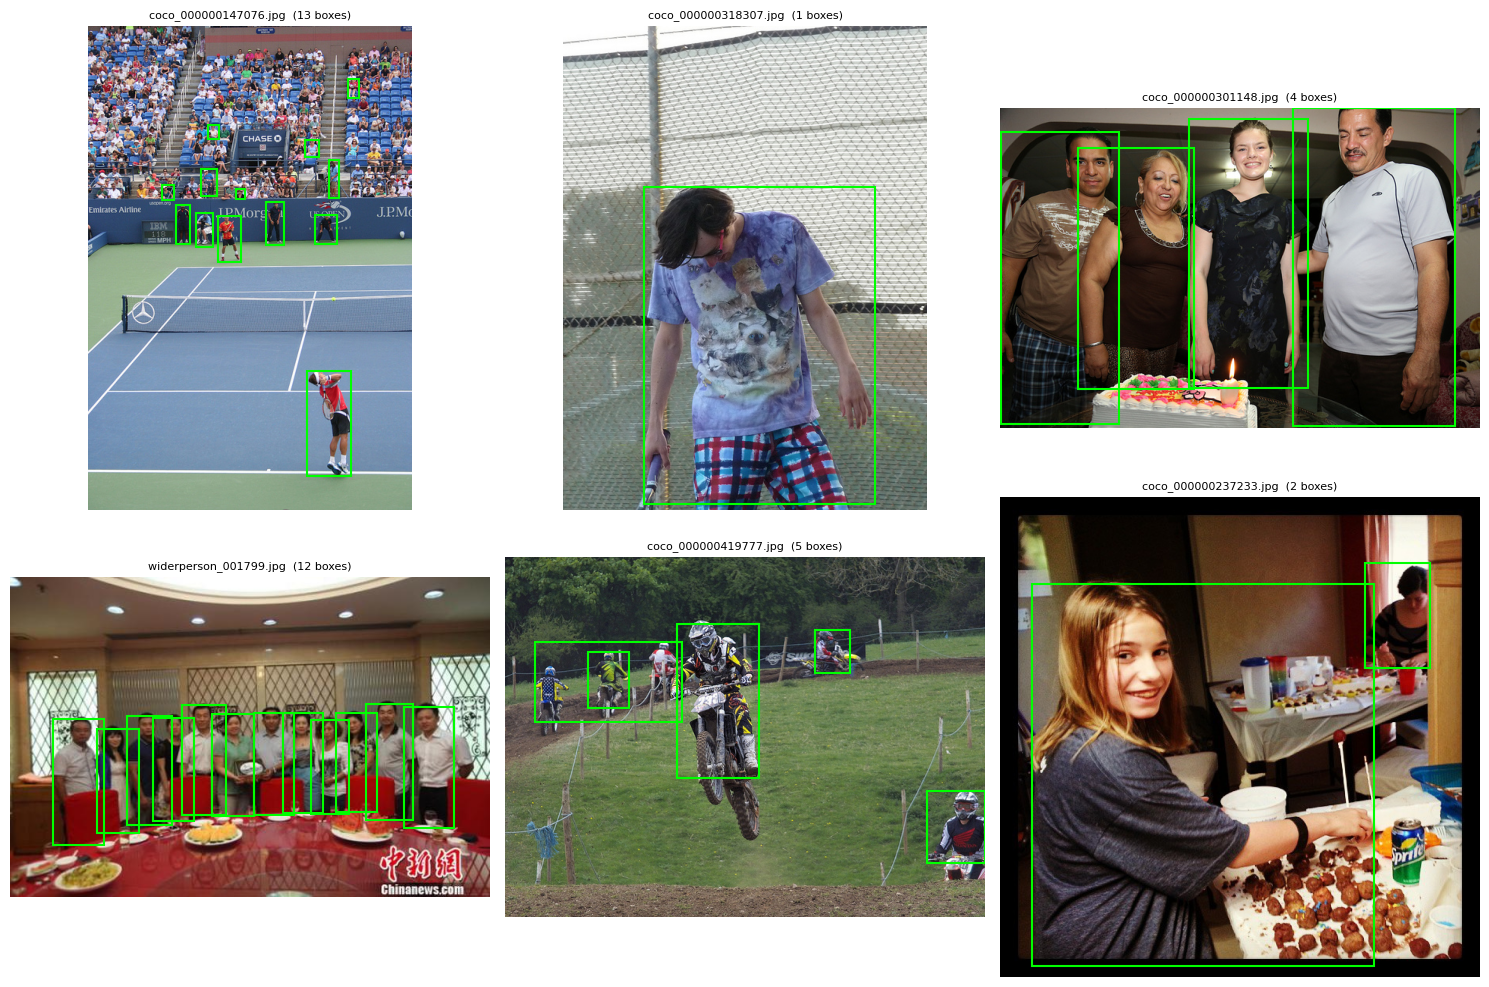

VAL samples:


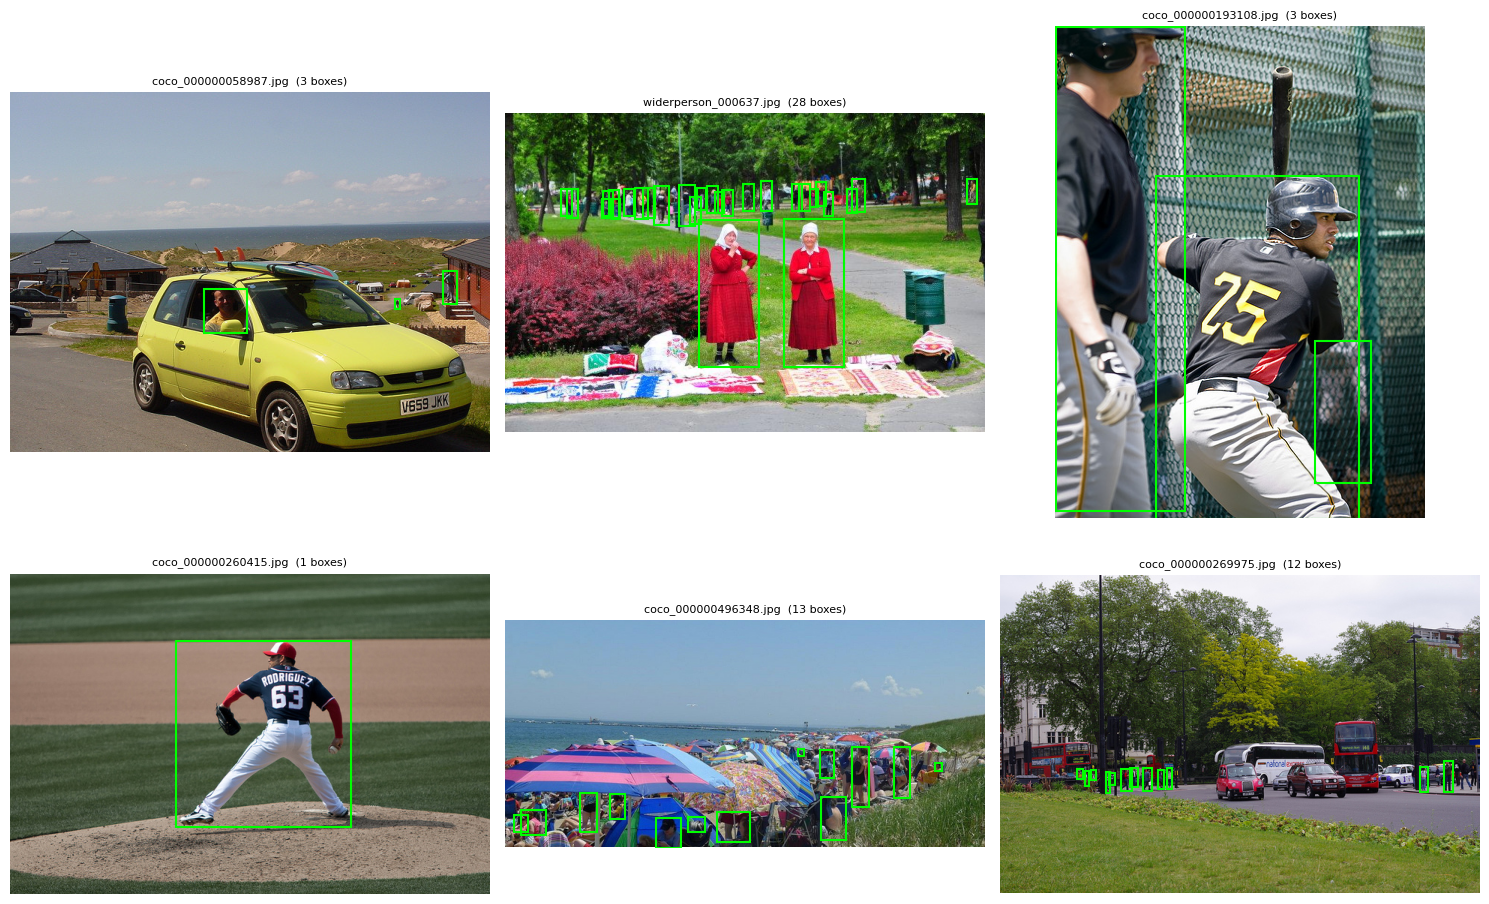


Label sanity scan:
  /kaggle/working/person_bulk_yolo/labels/train: 65717 label files, 0 with issues
  /kaggle/working/person_bulk_yolo/labels/val: 7301 label files, 0 with issues


In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def draw_yolo_sample(img_path, lbl_path, ax):
    """Draw an image and its YOLO labels (denormalized back to pixels)."""
    with Image.open(img_path) as im:
        im = im.convert("RGB")
        W, H = im.size
        ax.imshow(im)

    n = 0
    if os.path.exists(lbl_path):
        with open(lbl_path) as f:
            for line in f:
                parts = line.split()
                if len(parts) != 5:
                    continue
                cls, cx, cy, bw, bh = parts
                cx, cy, bw, bh = float(cx), float(cy), float(bw), float(bh)
                x1 = (cx - bw / 2.0) * W
                y1 = (cy - bh / 2.0) * H
                ax.add_patch(patches.Rectangle(
                    (x1, y1), bw * W, bh * H,
                    linewidth=1.5, edgecolor="lime", facecolor="none"))
                n += 1
    ax.set_title(f"{os.path.basename(img_path)}  ({n} boxes)", fontsize=8)
    ax.axis("off")

def verify_split(img_dir, lbl_dir, k=6):
    imgs = sorted(glob.glob(os.path.join(img_dir, "*")))
    if not imgs:
        print(f"  No images in {img_dir}")
        return
    picks = random.sample(imgs, min(k, len(imgs)))
    cols = 3
    rows = (len(picks) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
    axes = np.array(axes).reshape(-1)
    for ax in axes:
        ax.axis("off")
    for ax, img_path in zip(axes, picks):
        stem = os.path.splitext(os.path.basename(img_path))[0]
        draw_yolo_sample(img_path, os.path.join(lbl_dir, stem + ".txt"), ax)
    plt.tight_layout()
    plt.show()

print("TRAIN samples (mix of COCO + WiderPerson):")
verify_split(IMG_TRAIN_DIR, LBL_TRAIN_DIR)
print("VAL samples:")
verify_split(IMG_VAL_DIR, LBL_VAL_DIR)

# Label sanity pass over the whole output: catch out-of-range or malformed lines.
def sanity_scan(lbl_dir):
    bad = 0
    files = glob.glob(os.path.join(lbl_dir, "*.txt"))
    for lp in files:
        with open(lp) as f:
            for line in f:
                p = line.split()
                if len(p) != 5:
                    bad += 1; break
                cls = int(p[0])
                vals = list(map(float, p[1:]))
                if cls != PERSON_CLASS_ID or any(v < 0 or v > 1 for v in vals):
                    bad += 1; break
    print(f"  {lbl_dir}: {len(files)} label files, {bad} with issues")

print("\nLabel sanity scan:")
sanity_scan(LBL_TRAIN_DIR)
sanity_scan(LBL_VAL_DIR)

## 9. Disk Usage & Cleanup

In [12]:
print("Output dataset contents:")
!du -sh {OUTPUT_DIR}/* 2>/dev/null

print("\nImage / label counts:")
for split in ("train", "val"):
    ni = len(glob.glob(os.path.join(OUTPUT_DIR, "images", split, "*")))
    nl = len(glob.glob(os.path.join(OUTPUT_DIR, "labels", split, "*.txt")))
    print(f"  {split}: {ni} images, {nl} labels")

total_size = sum(
    os.path.getsize(os.path.join(dp, f))
    for dp, dn, fns in os.walk(OUTPUT_DIR) for f in fns
)
print(f"\nTotal output size: {total_size / (1024**3):.2f} GB")

# Kaggle's version-commit step inventories every output file individually, which
# stalls on datasets made of many small files. Pack the whole tree into one
# archive so the commit handles a single file. The working dir is too small to
# hold the tree and the archive at once, so the archive is built on the larger
# overlay scratch space first, then moved back after the tree is removed.
import zipfile

STAGE_PATH = "/tmp/person_bulk_yolo.zip"            # overlay scratch (terabytes free)
ARCHIVE_PATH = os.path.join(WORK_DIR, "person_bulk_yolo.zip")

file_list = []
for dp, dn, fns in os.walk(OUTPUT_DIR):
    for f in fns:
        file_list.append(os.path.join(dp, f))

print(f"\nArchiving {len(file_list):,} files -> {STAGE_PATH}")
with zipfile.ZipFile(STAGE_PATH, "w", compression=zipfile.ZIP_STORED) as zf:
    for i, fp in enumerate(file_list):
        # arcname relative to WORK_DIR keeps the leading person_bulk_yolo/ prefix
        zf.write(fp, arcname=os.path.relpath(fp, WORK_DIR))
        if i % 10000 == 0:
            print(f"  {i:,}/{len(file_list):,}")

stage_size = os.path.getsize(STAGE_PATH)
print(f"Archive staged: {stage_size / (1024**3):.2f} GB")

# Sanity-check the archive is complete before destroying the source tree.
with zipfile.ZipFile(STAGE_PATH) as zf:
    n_in_zip = len(zf.namelist())
    bad = zf.testzip()  # returns name of first corrupt file, or None
assert bad is None, f"Corrupt entry in archive: {bad}"
assert n_in_zip == len(file_list), f"Count mismatch: {n_in_zip} in zip vs {len(file_list)} on disk"
print(f"Archive verified: {n_in_zip:,} entries, integrity OK.")

# Now safe to remove the unpacked tree, freeing the working dir.
shutil.rmtree(OUTPUT_DIR)
print(f"Removed unpacked tree {OUTPUT_DIR}.")

# Move the finished archive into the working dir (single-file output for commit).
shutil.move(STAGE_PATH, ARCHIVE_PATH)
print(f"Moved archive into working dir: {ARCHIVE_PATH} "
      f"({os.path.getsize(ARCHIVE_PATH) / (1024**3):.2f} GB)")

# WiderPerson raw files can also be removed to free space.
if os.path.exists(WIDER_DIR) and os.path.abspath(WIDER_DIR).startswith(WORK_DIR):
    shutil.rmtree(WIDER_DIR)
    print(f"Removed {WIDER_DIR}.")
else:
    print(f"WiderPerson is read-only input or absent; nothing to clean ({WIDER_DIR}).")

print("\nReady to Save Version — output is a single verified archive.")

Output dataset contents:
4.0K	/kaggle/working/person_bulk_yolo/dataset_metadata.json
4.0K	/kaggle/working/person_bulk_yolo/data.yaml
11G	/kaggle/working/person_bulk_yolo/images
290M	/kaggle/working/person_bulk_yolo/labels

Image / label counts:
  train: 65717 images, 65717 labels
  val: 7301 images, 7301 labels

Total output size: 10.50 GB

Archiving 146,038 files -> /tmp/person_bulk_yolo.zip
  0/146,038
  10,000/146,038
  20,000/146,038
  30,000/146,038
  40,000/146,038
  50,000/146,038
  60,000/146,038
  70,000/146,038
  80,000/146,038
  90,000/146,038
  100,000/146,038
  110,000/146,038
  120,000/146,038
  130,000/146,038
  140,000/146,038
Archive staged: 10.53 GB
Archive verified: 146,038 entries, integrity OK.
Removed unpacked tree /kaggle/working/person_bulk_yolo.
Moved archive into working dir: /kaggle/working/person_bulk_yolo.zip (10.53 GB)
WiderPerson is read-only input or absent; nothing to clean (/kaggle/input/datasets/ritaj1/widerperson).

Ready to Save Version — output is 

## 10. Summary & Next Steps

### What was created

| Path | Description |
|------|-------------|
| `images/train`, `images/val` | Survivor images, source-prefixed filenames |
| `labels/train`, `labels/val` | YOLO `.txt` labels (one line per person box, class 0) |
| `data.yaml` | YOLO dataset descriptor (person=0, drone=1) |
| `dataset_metadata.json` | Dataset statistics, source breakdown, and layout |

### How to use downstream

After this notebook finishes, save the output as a Kaggle dataset: click **Save Version → Save & Run All**, then from the notebook's output click **New Dataset** and publish it as the interim person-bulk slug. The unifier notebook attaches this dataset (alongside the drone sources) as input and references the YOLO output directly under `images/{train,val}`, `labels/{train,val}`, and `data.yaml`.

### Next step

Drone-source notebooks (Svanström, DUT, UETT4K) and the field-collection set, each emitting the same YOLO layout, then the unifier notebook that merges, subsamples the person class to the locked ratio, splits, and packages the final dataset.